In [1]:

import numpy as np
from scipy.signal import hilbert
import matplotlib.pyplot as plt
import os
import pandas as pd
from scipy.signal import butter, filtfilt


正在处理: BF ...
正在处理: OR ...
正在处理: OR&BF ...


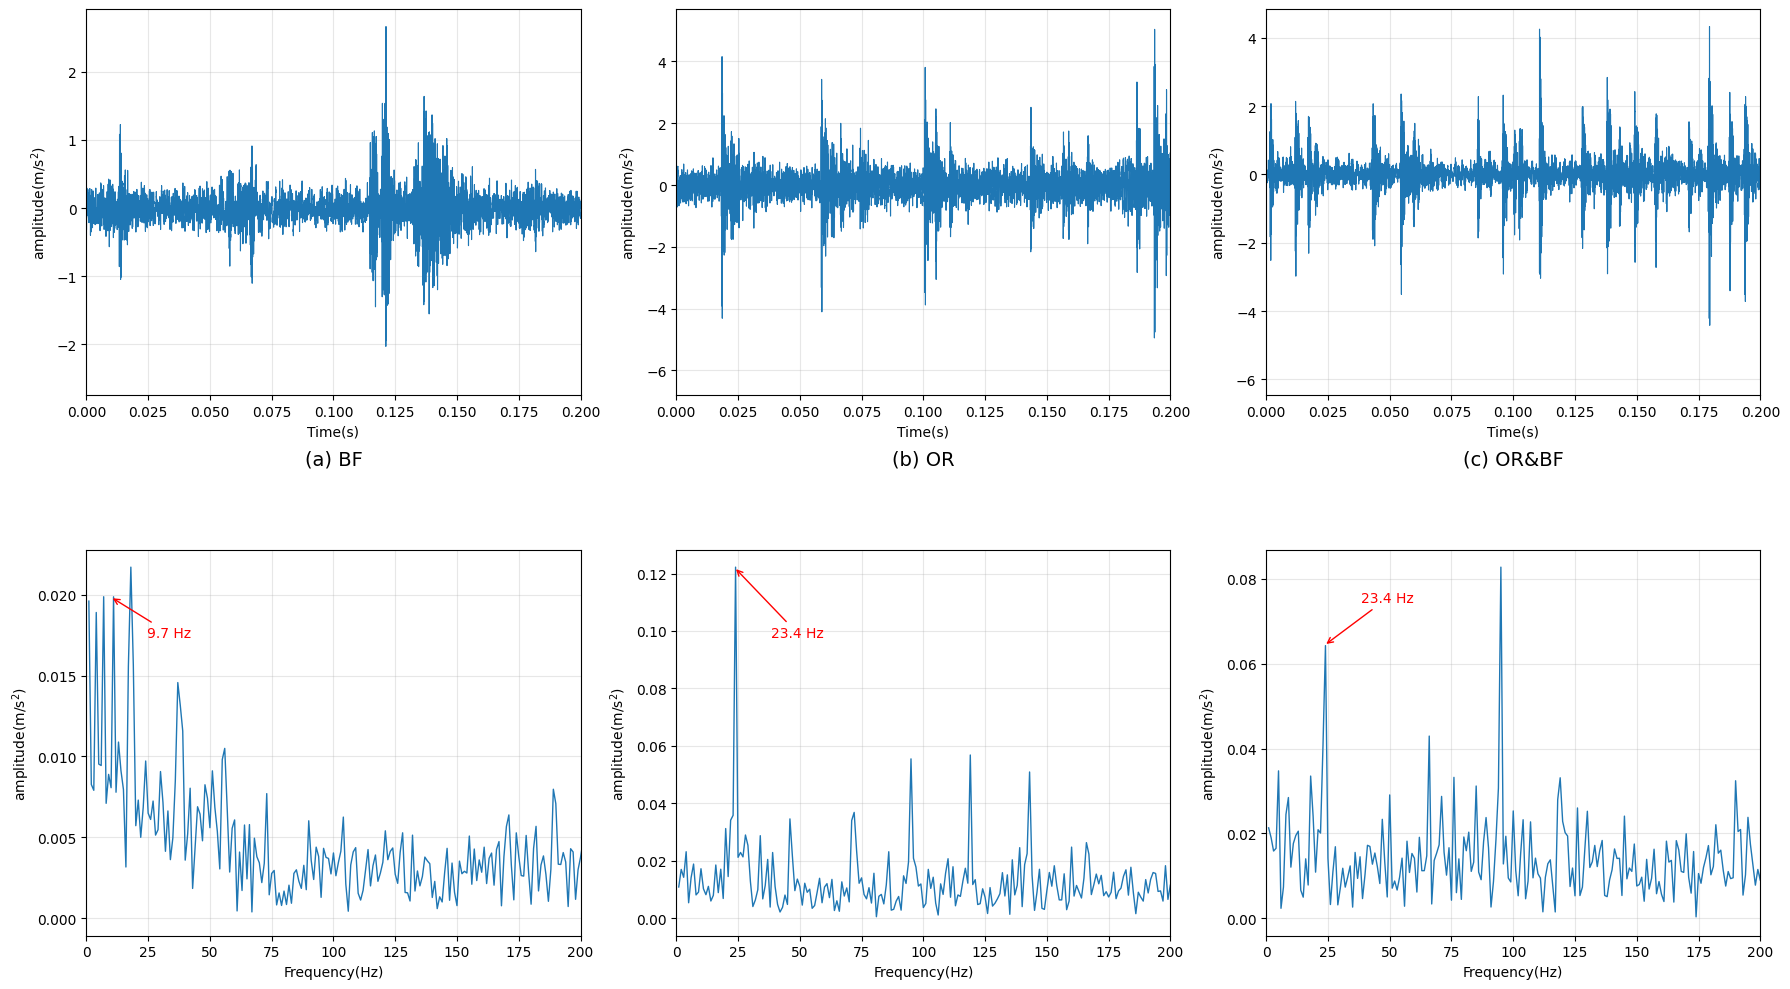

In [2]:
# ==========================================
# 3. 核心数学函数
# ==========================================
# 1. 增加一个带通滤波器，只保留故障引起的共振频段 (比如 2kHz - 20kHz)
def bandpass_filter(signal, fs=64000, low=2000, high=20000):
    nyq = 0.5 * fs
    low_cut = low / nyq
    high_cut = high / nyq
    b, a = butter(4, [low_cut, high_cut], btype='band')
    return filtfilt(b, a, signal)

def get_envelope_spectrum(signal, fs=64000):
    # 第一步：先进行带通滤波，消除低频晃动的干扰
    filtered_sig = bandpass_filter(signal, fs)
    
    # 第二步：计算希尔伯特包络
    analytic_signal = hilbert(filtered_sig)
    amplitude_envelope = np.abs(analytic_signal)
    
    # 第三步：去趋势处理（防止 0Hz 附近的抬升）
    amplitude_envelope -= np.mean(amplitude_envelope)
    
    n = len(amplitude_envelope)
    freqs = np.fft.fftfreq(n, 1/fs)
    fft_values = np.abs(np.fft.fft(amplitude_envelope)) / n
    mask = freqs > 0
    return freqs[mask], fft_values[mask]

# ==========================================
# 2. 数据读取函数：适配您的目录结构
# ==========================================
def fetch_one_sample(base_path, fault_label, component='leftaxlebox', channel='CH17', length=64000):
    """
    从指定故障文件夹中读取一个 20Hz_0kN 的样本
    length: 默认取 12800 点 (约 0.2s)，能清晰看到周期冲击
    """
    label_path = os.path.join(base_path, fault_label, 'Sample_1')
    csv_file = [f for f in os.listdir(label_path) if "20Hz_0kN" in f and component in f][0]
    df = pd.read_csv(os.path.join(label_path, csv_file))
    sig = df[channel].values[:length]
    # 转换为 m/s^2 (假设数据单位为g，乘以9.8；BJTU原始通常为g)
    return sig

# ==========================================
# 3. 主绘图逻辑
# ==========================================
def plot_paper_figure_4(data_root):
    fs = 64000
    # 定义 Task A 的三类文件夹 [cite: 720, 727]
    fault_map = {
        'BF': 'M0_G0_LA3_RA0',       # 滚子故障
        'OR': 'M0_G0_LA2_RA0',       # 外圈故障
        'OR&BF': 'M0_G0_LA2+LA3_RA0' # 复合故障
    }
    
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    titles = ['(a) BF', '(b) OR', '(c) OR&BF']
    # 理论特征频率 (20Hz转速下) [cite: 399, 387, 653]
    fcf_bf = 9.7 
    fcf_or = 23.4

    for i, (key, label) in enumerate(fault_map.items()):
        print(f"正在处理: {key} ...")
        sig = fetch_one_sample(data_root, label)
        t = np.arange(len(sig)) / fs
        
        # --- 第一行: 时域图 ---
        axes[0, i].plot(t, sig, color='#1f77b4', linewidth=0.8)
        axes[0, i].set_title(titles[i], fontsize=14, y=-0.2)
        axes[0, i].set_xlabel('Time(s)')
        axes[0, i].set_ylabel('amplitude(m/s$^2$)')
        axes[0, i].set_xlim(0, 0.2) # 限制时间范围便于观察冲击
        axes[0, i].grid(True, alpha=0.3)

        # --- 第二行: 包络谱 ---
        f, p = get_envelope_spectrum(sig, fs)
        axes[1, i].plot(f, p, color='#1f77b4', linewidth=1)
        axes[1, i].set_xlabel('Frequency(Hz)')
        axes[1, i].set_ylabel('amplitude(m/s$^2$)')
        axes[1, i].set_xlim(0, 200) # 对标论文，观察200Hz以内
        axes[1, i].grid(True, alpha=0.3)
        
        # 标注特征频率 (参考论文图 4 的标注方式)
        if key == 'BF':
            axes[1, i].annotate(f'{fcf_bf} Hz', xy=(fcf_bf, np.max(p[np.abs(f-fcf_bf)<2])), 
                                 xytext=(fcf_bf+15, np.max(p)*0.8), color='red',
                                 arrowprops=dict(arrowstyle='->', color='red'))
        elif key == 'OR':
            axes[1, i].annotate(f'{fcf_or} Hz', xy=(fcf_or, np.max(p[np.abs(f-fcf_or)<2])), 
                                 xytext=(fcf_or+15, np.max(p)*0.8), color='red',
                                 arrowprops=dict(arrowstyle='->', color='red'))
        elif key == 'OR&BF':
            # 复合故障同时标注两个频率
            axes[1, i].annotate(f'{fcf_or} Hz', xy=(fcf_or, np.max(p[np.abs(f-fcf_or)<2])), 
                                 xytext=(fcf_or+15, np.max(p)*0.9), color='red',
                                 arrowprops=dict(arrowstyle='->', color='red'))

    plt.tight_layout()
    plt.subplots_adjust(hspace=0.4)
    plt.savefig('my_dataset_features.png', dpi=300)
    plt.show()
# ==========================================
# 运行
# ==========================================
if __name__ == "__main__":
    DATA_PATH = r"E:\BaiduNetdiskDownload\BJTU-RAO Bogie Datasets\Data\BJTU_RAO_Bogie_Datasets\BJTU_RAO_Bogie_Datasets"
    plot_paper_figure_4(DATA_PATH)